<a href="https://colab.research.google.com/github/seungmei/QNS/blob/main/huckel_simulation_PTCDA%2BFe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hückel simulation — PTCDA + Fe

**Structure**
1. Parameters + Engine
2. Spectrum + Visualization helpers
3. Benzene (validation)
4. PTCDA + Fe series

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
plt.rcParams.update({'font.size': 10, 'axes.facecolor': '#0a0a0a',
                     'figure.facecolor': '#050505', 'axes.edgecolor': '#333'})

---
## 1. Parameters + Engine

| Parameter | Meaning |
|---|---|
| `h_O`, `h_Fe` | On-site energy (electronegativity relative to C = 0) |
| `k_CC`, `k_CO`, `k_FeO` | Bond hopping integrals |
| `coulomb_de` | Electrostatic stabilization per Fe atom |
| `beta` | Energy unit (eV). Negative → bonding orbital has lower energy |
| `gamma` | Peak width (thermal + instrumental broadening) |
| `e_scale`, `e_offset` | Hückel energy → experimental voltage: `V = E × e_scale + e_offset` |

`huckel(atoms, bonds)` builds the matrix **and** diagonalizes in one call — replaces the old `build_hamiltonian` + `solve` split.

In [8]:
PARAMS = {
    # On-site energies (electronegativity relative to C=0)
    'h_O':  2.0,   'h_Fe': 0.8,
    # Bond strengths (hopping integrals relative to k_CC=1)
    'k_CC': 1.0,   'k_CO': 0.8,   'k_FeO': 0.5,
    # Electrostatic stabilization per Fe (shifts all PTCDA diagonals)
    'coulomb_de': 0.15,
    # Energy unit and broadening
    'beta': -1.0,  'gamma': 0.18,
    # Hückel energy → experimental voltage:  V = E * e_scale + e_offset
    'e_scale': 0.7, 'e_offset': -1.8,
}

V = np.linspace(-4.5, 1, 600)   # voltage axis — defined once

_H_ONSITE = {'C': 0, 'O': 'h_O', 'Fe': 'h_Fe'}
_K_BOND = {frozenset(['C', 'C']): 'k_CC',
           frozenset(['C', 'O']): 'k_CO',
           frozenset(['C', 'Fe']): 'k_FeO',
           frozenset(['Fe', 'O']): 'k_FeO'}


def huckel(atoms, bonds):
    """Build Hückel matrix and diagonalize in one call.
    Returns (energies, orbitals) sorted by energy (lowest first).
    Diagonal: h_X * beta.  Off-diagonal: k_XY * beta.
    Fe electrostatic shift: lowers every non-Fe diagonal by coulomb_de * n_Fe * |beta|.
    """
    P = PARAMS
    n = len(atoms)
    H = np.zeros((n, n))

    for i, a in enumerate(atoms):
        key = _H_ONSITE.get(a)
        H[i, i] = (P[key] if key else 0) * P['beta']

    n_fe = atoms.count('Fe')
    if n_fe:
        for i, a in enumerate(atoms):
            if a != 'Fe':
                H[i, i] += P['coulomb_de'] * n_fe * P['beta']

    for i, j in bonds:
        pair = frozenset([atoms[i], atoms[j]])
        k_key = _K_BOND.get(pair)
        v = (P[k_key] if k_key else 0.5) * P['beta']
        H[i, j] = H[j, i] = v

    energies, orbitals = np.linalg.eigh(H)
    order = np.argsort(energies)
    return energies[order], orbitals[:, order]

---
## 2. Spectrum + Visualization

- `didv` / `ldos` — Lorentzian-broadened DOS and per-atom LDOS
- `draw_mol` — draw molecule with orbital (`mode='mo'`) or LDOS (`mode='ldos'`) coloring
- `spring_layout` — 2D layout for drawing (eigenvalues don't depend on positions)
- `plot_fe_series` — produces all 3 figures for the PTCDA/Fe series in one call

In [9]:
def to_V(e):
    """Hückel energy (β units) → experimental voltage (V)."""
    return e * PARAMS['e_scale'] + PARAMS['e_offset']


def didv(energies, orbitals=None, V=V, tip_atoms=None):
    """dI/dV spectrum. tip_atoms=None → total DOS (기존과 동일)."""
    g = PARAMS['gamma']
    dIdV = np.zeros_like(V)
    for n, E in enumerate(energies):
        w = 1.0 if tip_atoms is None else sum(orbitals[i, n]**2 for i in tip_atoms)
        dIdV += w * g / (np.pi * ((V - to_V(E))**2 + g**2))
    return dIdV


def ldos(energies, orbitals, V):
    """Per-atom LDOS:  ρᵢ(V) = Σₙ |cᵢₙ|² · L(V − Eₙ)"""
    g = PARAMS['gamma']
    out = np.zeros((orbitals.shape[0], len(V)))
    for n, E in enumerate(energies):
        peak = g / (np.pi * ((V - to_V(E))**2 + g**2))
        out += (orbitals[:, n]**2)[:, None] * peak[None, :]
    return out


def draw_mol(ax, xy, bonds, atoms, values=None, mode='mo'):
    """Draw molecule. mode='mo': blue/red circles. mode='ldos': inferno."""
    from matplotlib.cm import inferno
    ax.set_aspect('equal'); ax.set_facecolor('#0a0a0a'); ax.axis('off')
    atom_color = {'C': '#666', 'O': '#dc2626', 'Fe': '#fbbf24'}
    for i, j in bonds:
        ax.plot([xy[i][0], xy[j][0]], [xy[i][1], xy[j][1]], '#333', lw=0.8)
    if values is not None:
        mx = max(abs(values)) + 1e-10
        for i in range(len(atoms)):
            r = abs(values[i]) / mx * 0.4 + 0.03
            if mode == 'mo':
                color = '#3b82f6' if values[i] >= 0 else '#ef4444'
                ax.add_patch(plt.Circle(xy[i], r, color=color, alpha=0.45))
            else:
                ax.add_patch(plt.Circle(xy[i], r, color=inferno(values[i]/mx), alpha=0.7))
    ms_map = {'C': 2, 'O': 3, 'Fe': 5}
    for i, a in enumerate(atoms):
        ax.plot(*xy[i], 'o', color=atom_color.get(a, '#888'), ms=ms_map.get(a, 3))
        if a == 'Fe':
            ax.plot(*xy[i], 's', mfc='none', mec='#fbbf24', mew=1.5, ms=10)


def spring_layout(atoms, bonds, seed=42):
    """2D spring-embedder layout (drawing only)."""
    n = len(atoms)
    np.random.seed(seed)
    pos = np.random.randn(n, 2) * 2
    for _ in range(400):
        f = np.zeros_like(pos)
        for i in range(n):
            for j in range(i + 1, n):
                d = pos[i] - pos[j]; r = max(np.linalg.norm(d), 0.01)
                f[i] += 1.5 * d / r**3; f[j] -= 1.5 * d / r**3
        for i, j in bonds:
            d = pos[j] - pos[i]; r = max(np.linalg.norm(d), 0.01)
            pull = 2 * (r - 1) * d / r; f[i] += pull; f[j] -= pull
        pos += 0.02 * f
    return pos - pos.mean(0)


COLORS = ['#3b82f6', '#22c55e', '#f59e0b', '#ef4444', '#a855f7']
LABELS = ['PTCDA', '1 Fe', '2 Fe', '3 Fe', '4 Fe']


def plot_fe_series(results):
    """Produces 3 figures: dI/dV overlay, HOMO orbital row, LDOS map row."""
    # Panel 1: dI/dV overlay
    fig, ax = plt.subplots(figsize=(14, 6))
    for i, r in enumerate(results):
        curve = didv(r['energies'], V)
        offset = i * 1.2
        ax.plot(V, curve + offset, color=COLORS[i], lw=2,
                label=f"{LABELS[i]}  (HOMO: {r['homo_V']:.3f} V)")
        ax.fill_between(V, offset, curve + offset, color=COLORS[i], alpha=0.06)
    ax.annotate('', xy=(results[-1]['homo_V'], -0.5),
                xytext=(results[0]['homo_V'], -0.5),
              )
    ax.set(xlabel='Sample Bias (V)', ylabel='dI/dV (a.u.)',
           title='bias V vs. dI/dV')
    ax.legend(fontsize=9); ax.grid(alpha=0.2)
    plt.tight_layout(); plt.show()

    # Panel 2: HOMO orbital row
    fig, axes = plt.subplots(1, 5, figsize=(28, 7))
    for i, r in enumerate(results):
        draw_mol(axes[i], r['xy'], r['bonds'], r['atoms'],
                 r['orbitals'][:, r['hi']], mode='mo')
        shift = r['homo_V'] - results[0]['homo_V']
        title = f"{LABELS[i]}\nHOMO = {r['homo_V']:.3f} V"
        if i: title += f"\nΔ = {shift:+.3f} V"
        axes[i].set_title(title, fontsize=12, fontweight='bold', color=COLORS[i])
    plt.suptitle('HOMO orbital (blue +, red −)', fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()

    # Panel 3: LDOS map row
    fig, axes = plt.subplots(1, 5, figsize=(28, 7))
    for i, r in enumerate(results):
        ldos_map = ldos(r['energies'], r['orbitals'], np.array([r['homo_V']]))[: , 0]
        draw_mol(axes[i], r['xy'], r['bonds'], r['atoms'], ldos_map, mode='ldos')
        axes[i].set_title(f"{LABELS[i]} | {r['homo_V']:.3f} V",
                          fontsize=11, fontweight='bold', color=COLORS[i])
    plt.suptitle('Spatial LDOS at HOMO bias (inferno)', fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()

---
## 3. Benzene (validation)

6C ring, 6 π-electrons.  
Expected eigenvalues / β: **[2, 1, 1, −1, −1, −2]**  
HOMO-LUMO gap: **2β**

Eigenvalues / β : [ 2.  1.  1. -1. -1. -2.]
Expected         : [2, 1, 1, -1, -1, -2]
Validation       : ✓ PASS
HOMO-LUMO gap    : 2.00 β  (expect 2.0 β)


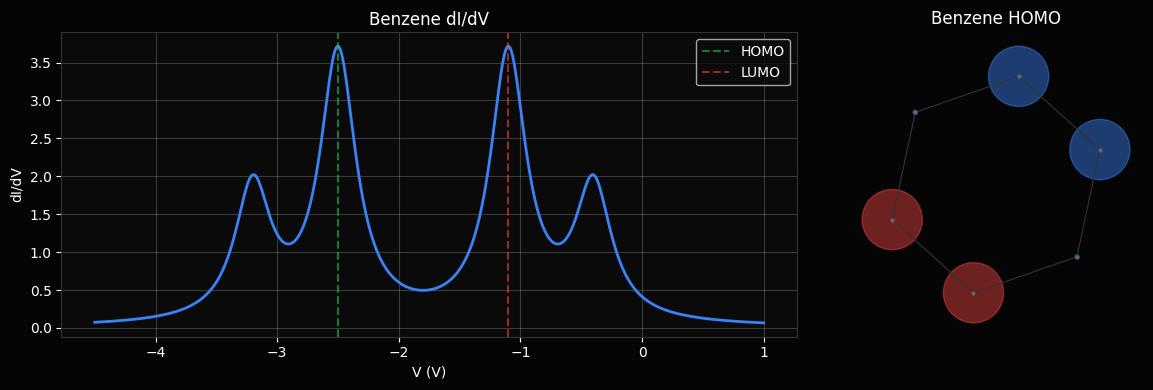

In [10]:
benz_atoms = ['C'] * 6
benz_bonds = [(i, (i + 1) % 6) for i in range(6)]
benz_ne = 6

energies_b, orbitals_b = huckel(benz_atoms, benz_bonds)
hi_b = benz_ne // 2 - 1  # HOMO index = 2

evals_beta = np.round(energies_b / PARAMS['beta'], 6)
print(f"Eigenvalues / β : {evals_beta}")
print(f"Expected         : [2, 1, 1, -1, -1, -2]")
ok = np.allclose(sorted(evals_beta), sorted([2, 1, 1, -1, -1, -2]), atol=1e-4)
print(f"Validation       : {'✓ PASS' if ok else '✗ FAIL'}")
print(f"HOMO-LUMO gap    : {energies_b[hi_b+1] - energies_b[hi_b]:.2f} β  (expect 2.0 β)")

xy_b = spring_layout(benz_atoms, benz_bonds)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4),
                                gridspec_kw={'width_ratios': [2, 1]})
ax1.plot(V, didv(energies_b, V), '#3b82f6', lw=2)
ax1.axvline(to_V(energies_b[hi_b]),   color='#22c55e', ls='--', alpha=0.6, label='HOMO')
ax1.axvline(to_V(energies_b[hi_b+1]), color='#ef4444', ls='--', alpha=0.6, label='LUMO')
ax1.set(xlabel='V (V)', ylabel='dI/dV', title='Benzene dI/dV')
ax1.legend(); ax1.grid(alpha=0.2)
draw_mol(ax2, xy_b, benz_bonds, benz_atoms, orbitals_b[:, hi_b], mode='mo')
ax2.set_title('Benzene HOMO')
plt.tight_layout(); plt.show()

---
## 4. PTCDA + Fe series

**Perylene core**: 5 peri-fused hexagonal rings (20 C).  
**Anhydride groups**: 4 exocyclic C + 4 carbonyl O (=O, 1e⁻ each) + 2 bridge O (–O–, 2e⁻ each).  
**Total π-electrons**: 24×1 + 4×1 + 2×2 = **32**

`make_ptcda_fe(n_fe)` attaches 1–4 Fe to carbonyl oxygens (atoms 24–27).  
Fe contributes **0 π-electrons** but shifts HOMO via two mechanisms:
- **Delocalization** (`k_FeO`): off-diagonal coupling extends the π-system
- **Electrostatic** (`coulomb_de`): Fe⁺ Coulomb attraction lowers all PTCDA diagonals

In [11]:
perylene_bonds = [
    (0,1),(1,2),(2,3),(3,4),(4,5),(5,0),      # Ring A
    (0,6),(6,7),(7,8),(8,9),(9,5),             # Ring B
    (9,10),(10,11),(11,12),(12,7),             # Ring C (centre)
    (12,13),(13,14),(14,15),(15,10),           # Ring D
    (15,16),(16,17),(17,18),(18,19),(19,14),   # Ring E
]
anhydride_bonds = [
    (1,20),(2,21),(18,22),(19,23),             # exocyclic C
    (20,24),(21,25),(22,26),(23,27),           # carbonyl O (=O)
    (20,28),(21,28),(22,29),(23,29),           # bridge O (–O–)
]

ptcda_atoms = ['C'] * 24 + ['O'] * 6
ptcda_bonds = perylene_bonds + anhydride_bonds
ptcda_ne = 32
ptcda_xy = spring_layout(ptcda_atoms, ptcda_bonds)

print(f"PTCDA: {len(ptcda_atoms)} atoms, {ptcda_ne} π-electrons")


def make_ptcda_fe(n_fe):
    """PTCDA + n_fe Fe atoms on carbonyl oxygens."""
    atoms = list(ptcda_atoms)
    bonds = list(ptcda_bonds)
    xy = list(ptcda_xy)
    carbonyl_O = [24, 25, 26, 27]
    for i in range(min(n_fe, 4)):
        fe_idx = len(atoms)
        atoms.append('Fe')
        bonds.append((carbonyl_O[i], fe_idx))
        ox, oy = xy[carbonyl_O[i]]
        xy.append((ox + 0.8 * (1 if i % 2 else -1),
                   oy + 0.8 * (1 if i < 2 else -1)))
    return atoms, bonds, np.array(xy)

PTCDA: 30 atoms, 32 π-electrons


0 Fe: HOMO = -2.1492 V  (shift +0.0000 V)
1 Fe: HOMO = -2.3059 V  (shift -0.1567 V)
2 Fe: HOMO = -2.3796 V  (shift -0.2304 V)
3 Fe: HOMO = -2.4738 V  (shift -0.3246 V)
4 Fe: HOMO = -2.5800 V  (shift -0.4308 V)


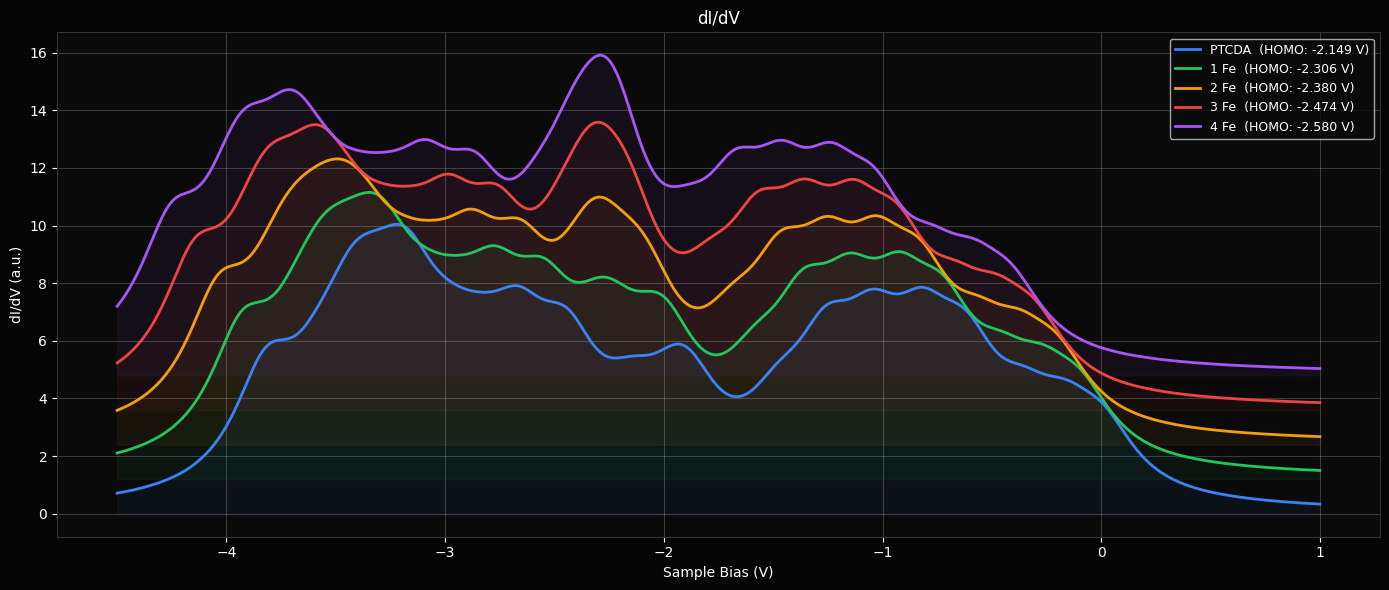

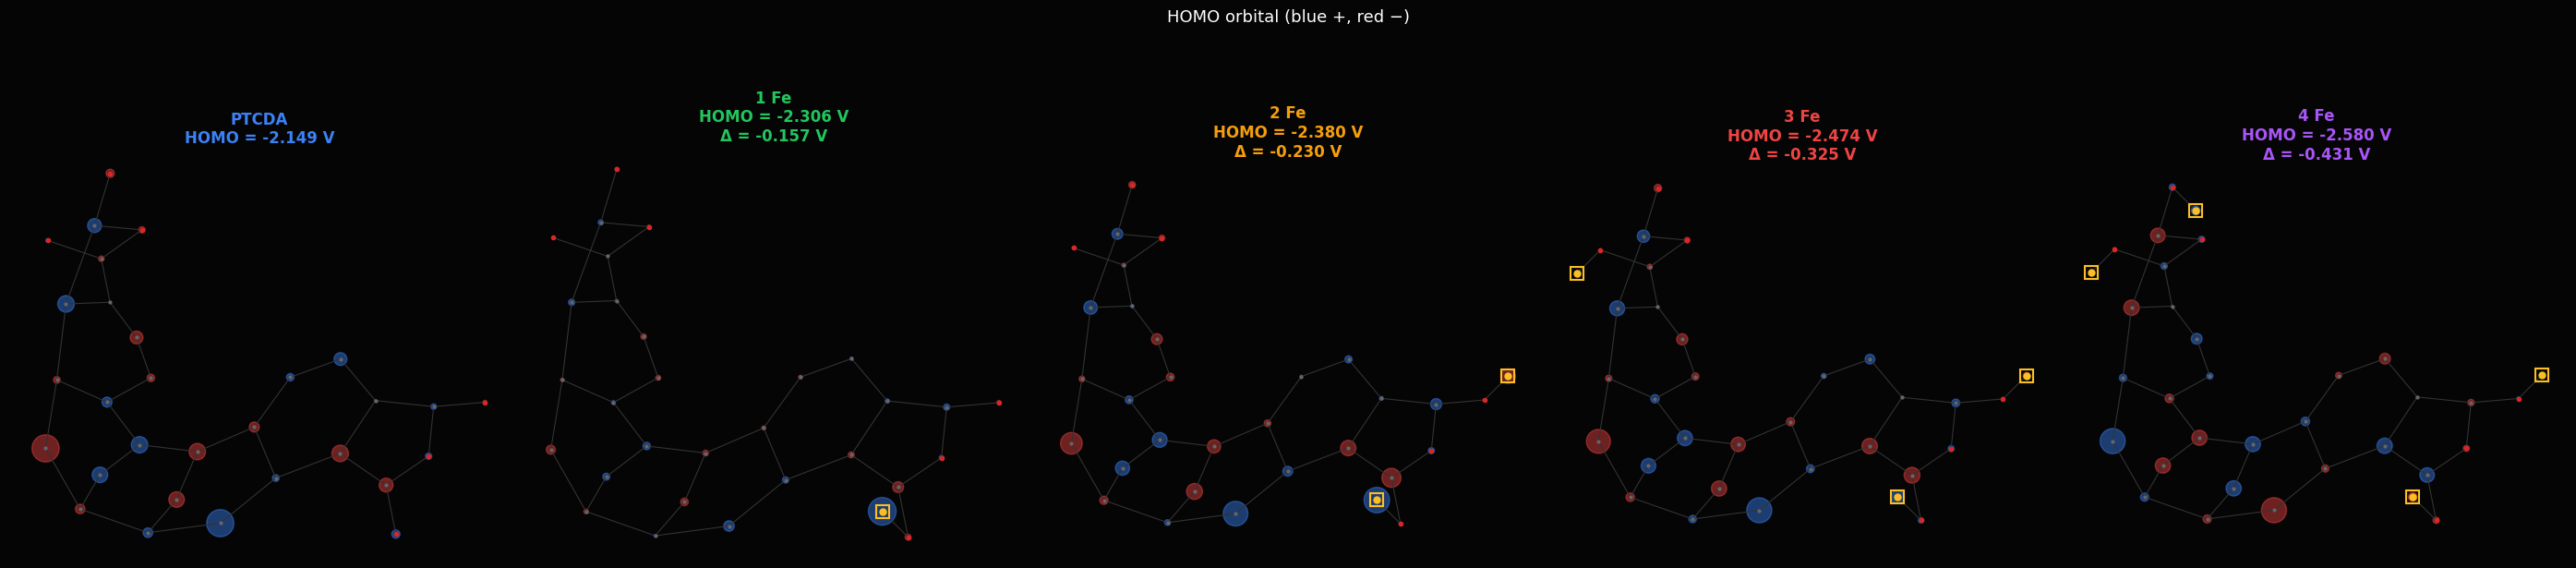

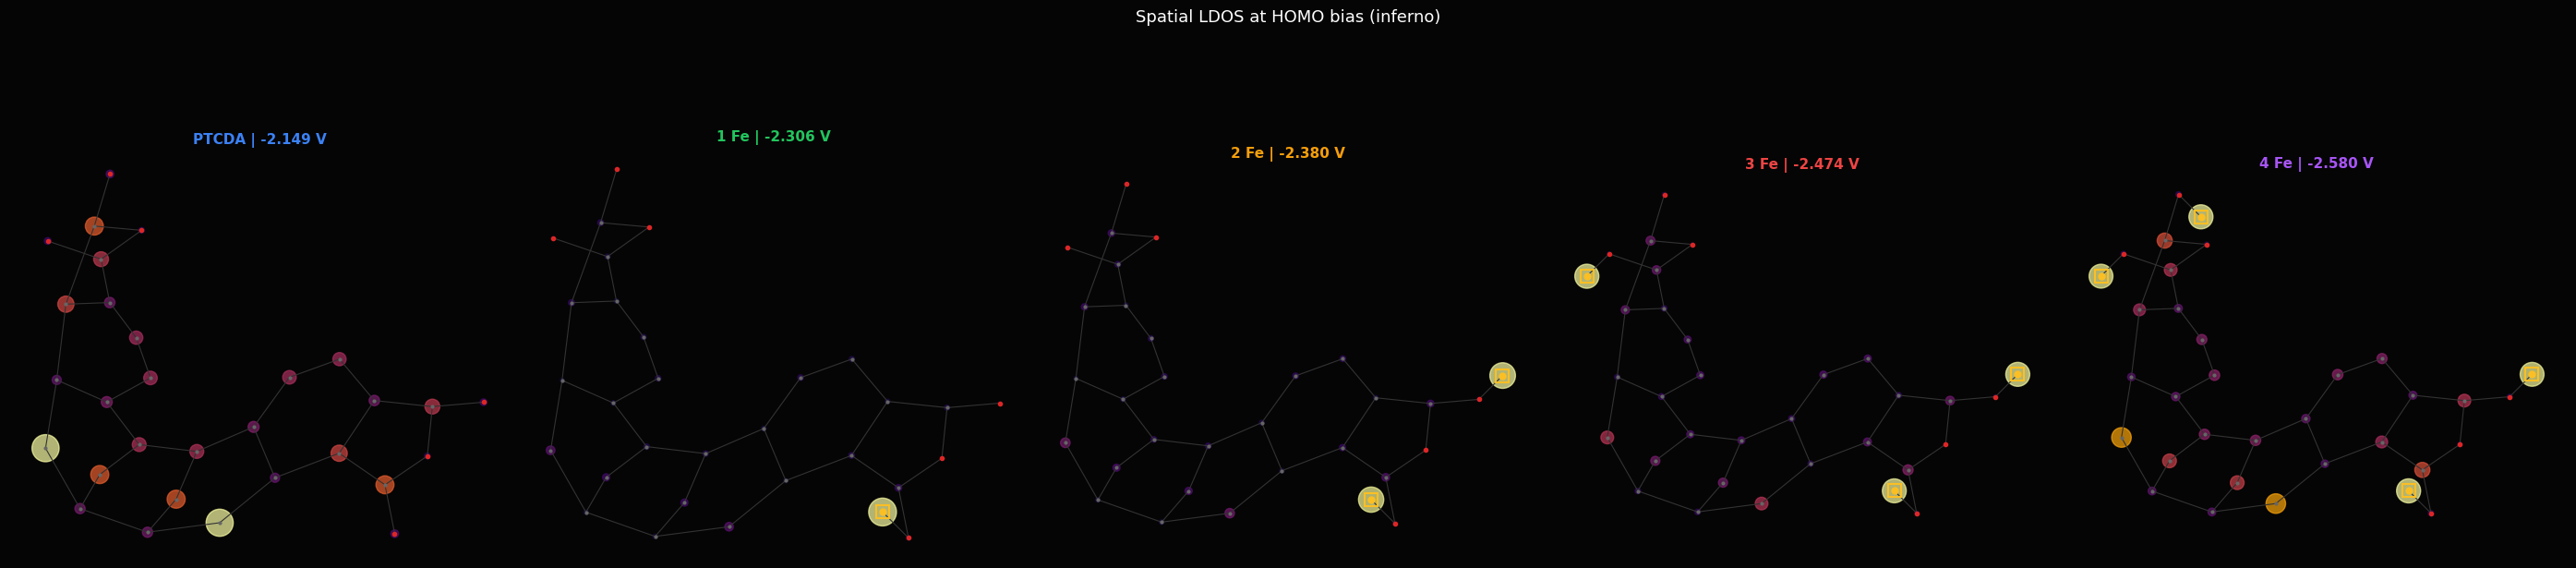

In [12]:

results = []
for n_fe in range(5):
    if n_fe == 0:
        atoms, bonds, xy = ptcda_atoms, ptcda_bonds, ptcda_xy
    else:
        atoms, bonds, xy = make_ptcda_fe(n_fe)

    energies_p, orbitals_p = huckel(atoms, bonds)
    hi = ptcda_ne // 2 - 1
    homo_V = to_V(energies_p[hi])

    results.append({'atoms': atoms, 'bonds': bonds, 'xy': xy,
                    'energies': energies_p, 'orbitals': orbitals_p,
                    'hi': hi, 'homo_V': homo_V})
    shift = homo_V - results[0]['homo_V']
    print(f"{n_fe} Fe: HOMO = {homo_V:.4f} V  (shift {shift:+.4f} V)")

plot_fe_series(results)